In [1]:
import yaml
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cobra.io import read_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from cobra.flux_analysis.parsimonious import optimize_minimal_flux

In [80]:
cell_type = "MCF7_core"

sbml_file = "../config/MCF7_Zielinski_2017_core.sbml"
model = read_sbml_model(sbml_file, f_replace={'F_REACTION': lambda x: x})

for r in model.reactions:
    if r.objective_coefficient != 0:
        objective_reaction = r.id
        break

print(f"Objective reaction: {objective_reaction}")

model.reactions.R_DM_gudac_c_.upper_bound = 0.0
model.reactions.R_biomass_reaction.lower_bound = 0.0
model.reactions.R_biomass_reaction.upper_bound = 0.1
model.reactions.R_DM_atp_c_.lower_bound = 0.0
model.reactions.R_DM_atp_c_.upper_bound = 100
model.reactions.R_ATPM.lower_bound = 1.07

model.reactions.R_EX_lac_L_e.upper_bound = 10.0
model.reactions.R_EX_lac_L_e.lower_bound = 0.0

Objective reaction: R_biomass_reaction


# Exploring limiting substrate
This part explores which are the limintg substrates for the model using reduced cost

In [3]:
eps = 1e-5

solution = model.optimize()
max_growth_rate = solution.objective_value
print(f"Base mode Max growth rate: {max_growth_rate} 1/hr")
print(solution.reduced_costs[solution.reduced_costs < -eps].head(30).sort_values())
print()

model.reactions.R_EX_thr_L_e.lower_bound = -1.0
model.reactions.R_EX_thr_L_e.upper_bound = 1.0
solution = model.optimize()
max_growth_rate = solution.objective_value
print(f"Relaxing Thr-L uptake Max growth rate: {max_growth_rate} 1/hr")
print(solution.reduced_costs[solution.reduced_costs < -eps].head(30).sort_values())
print()
model.reactions.R_EX_val_L_e.lower_bound = -1.0
model.reactions.R_EX_val_L_e.upper_bound = 1.0
solution = model.optimize()
max_growth_rate = solution.objective_value
print(f"Relaxing Val-L uptake Max growth rate: {max_growth_rate} 1/hr")
print(solution.reduced_costs[solution.reduced_costs < -eps].head(30).sort_values())
print()

model.reactions.R_EX_lys_L_e.lower_bound = -1.0
model.reactions.R_EX_lys_L_e.upper_bound = 1.0
solution = model.optimize()
max_growth_rate = solution.objective_value
print(f"Relaxing Lys-L uptake Max growth rate: {max_growth_rate} 1/hr")
print(solution.reduced_costs[solution.reduced_costs < -eps].head(30).sort_values())
print()

model.reactions.R_EX_phe_L_e.lower_bound = -1.0
model.reactions.R_EX_phe_L_e.upper_bound = 1.0
solution = model.optimize()
max_growth_rate = solution.objective_value
print(f"Relaxing Phe-L uptake Max growth rate: {max_growth_rate} 1/hr")
print(solution.reduced_costs[solution.reduced_costs < -eps].head(30).sort_values())
print()

model.reactions.R_EX_trp_L_e.lower_bound = -1.0
model.reactions.R_EX_trp_L_e.upper_bound = 1.0
solution = model.optimize()
max_growth_rate = solution.objective_value
print(f"Relaxing Trp-L uptake Max growth rate: {max_growth_rate} 1/hr")
print(solution.reduced_costs[solution.reduced_costs < -eps].head(30).sort_values())
print()

model.reactions.R_EX_leu_L_e.lower_bound = -1.0
model.reactions.R_EX_leu_L_e.upper_bound = 1.0
solution = model.optimize()
max_growth_rate = solution.objective_value
print(f"Relaxing Leu-L uptake Max growth rate: {max_growth_rate} 1/hr")
print(solution.reduced_costs[solution.reduced_costs < -eps].head(30).sort_values())
print()


Base mode Max growth rate: 0.026802255698138648 1/hr
R_EX_thr_L_e   -5.290947
R_THR3D        -5.290947
Name: reduced_costs, dtype: float64

Relaxing Thr-L uptake Max growth rate: 0.03103120787895499 1/hr
R_EX_val_L_e   -5.187336
R_OIVD2m       -5.187336
Name: reduced_costs, dtype: float64

Relaxing Val-L uptake Max growth rate: 0.034092126047787476 1/hr
R_EX_lys_L_e   -3.618487
R_AATAi        -3.618487
Name: reduced_costs, dtype: float64

Relaxing Lys-L uptake Max growth rate: 0.034577068201301346 1/hr
R_EX_phe_L_e   -11.71349
R_PHETHPTOX2   -11.71349
Name: reduced_costs, dtype: float64

Relaxing Phe-L uptake Max growth rate: 0.03594702478782806 1/hr
R_EX_trp_L_e   -50.191375
R_TRPO2        -50.191375
Name: reduced_costs, dtype: float64

Relaxing Trp-L uptake Max growth rate: 0.04123250657051018 1/hr
R_EX_leu_L_e   -3.645031
R_OIVD1m       -3.645031
Name: reduced_costs, dtype: float64

Relaxing Leu-L uptake Max growth rate: 0.06646278455967632 1/hr
R_EX_ile_L_e   -6.253661
R_PPCOACm   

# Phenotype Phase Space Analysis
Herea a PPA or envelop analysis is performed to investigate the degeneracy of the optimal solution respect to respiration and lactate fermentation

In [4]:
cell_type = "MCF7_core"

sbml_file = "../config/MCF7_Zielinski_2017_core.sbml"
model = read_sbml_model(sbml_file, f_replace={'F_REACTION': lambda x: x})

for r in model.reactions:
    if r.objective_coefficient != 0:
        objective_reaction = r.id
        break

print(f"Objective reaction: {objective_reaction}")

model.reactions.R_DM_gudac_c_.upper_bound = 0.0
model.reactions.R_biomass_reaction.lower_bound = 0.0
model.reactions.R_biomass_reaction.upper_bound = 0.1
model.reactions.R_DM_atp_c_.lower_bound = 0.0
model.reactions.R_DM_atp_c_.upper_bound = 0.0
model.reactions.R_ATPM.lower_bound = 1.07

model.reactions.R_EX_ala_L_e.upper_bound = 0.0
model.reactions.R_EX_cit_e.upper_bound = 0.0
model.reactions.R_EX_pro_L_e.upper_bound = 0.0


n = 150
lac_vals = np.linspace(0.0, 0.7, n)
o2_vals = np.linspace(0.0, 3.0, n)

LAC, O2 = np.meshgrid(lac_vals, o2_vals)

biomass = np.full((n,n), np.nan)
rc_o2 = np.full((n,n), np.nan)
rc_lac = np.full((n,n), np.nan)

lac_rxn = model.reactions.R_EX_lac_L_e
o2_rxn = model.reactions.R_EX_o2_e

for i in range(n):
    for j in range(n):

        lac = LAC[i,j]
        o2 = O2[i,j]
        lac_rxn.bounds = (lac, lac)
        o2_rxn.bounds = (-o2, -o2)

        sol = model.optimize()

        if sol.status == "optimal":
            biomass[i,j] = sol.fluxes["R_biomass_reaction"]
            rc_o2[i,j] = sol.reduced_costs["R_EX_o2_e"]
            rc_lac[i,j] = sol.reduced_costs["R_EX_lac_L_e"]
        else:
            biomass[i,j] = 0.0
            rc_o2[i,j] = 0.0
            rc_lac[i,j] = 0.0

tol = 1e-6

Objective reaction: R_biomass_reaction


/home/mponce/projects/devel/PhysiCelldFBA/venv/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


[np.float64(0.0), np.float64(0.5610607881132839), np.float64(-0.4), np.float64(-0.1)]


/tmp/ipykernel_12200/2207496769.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


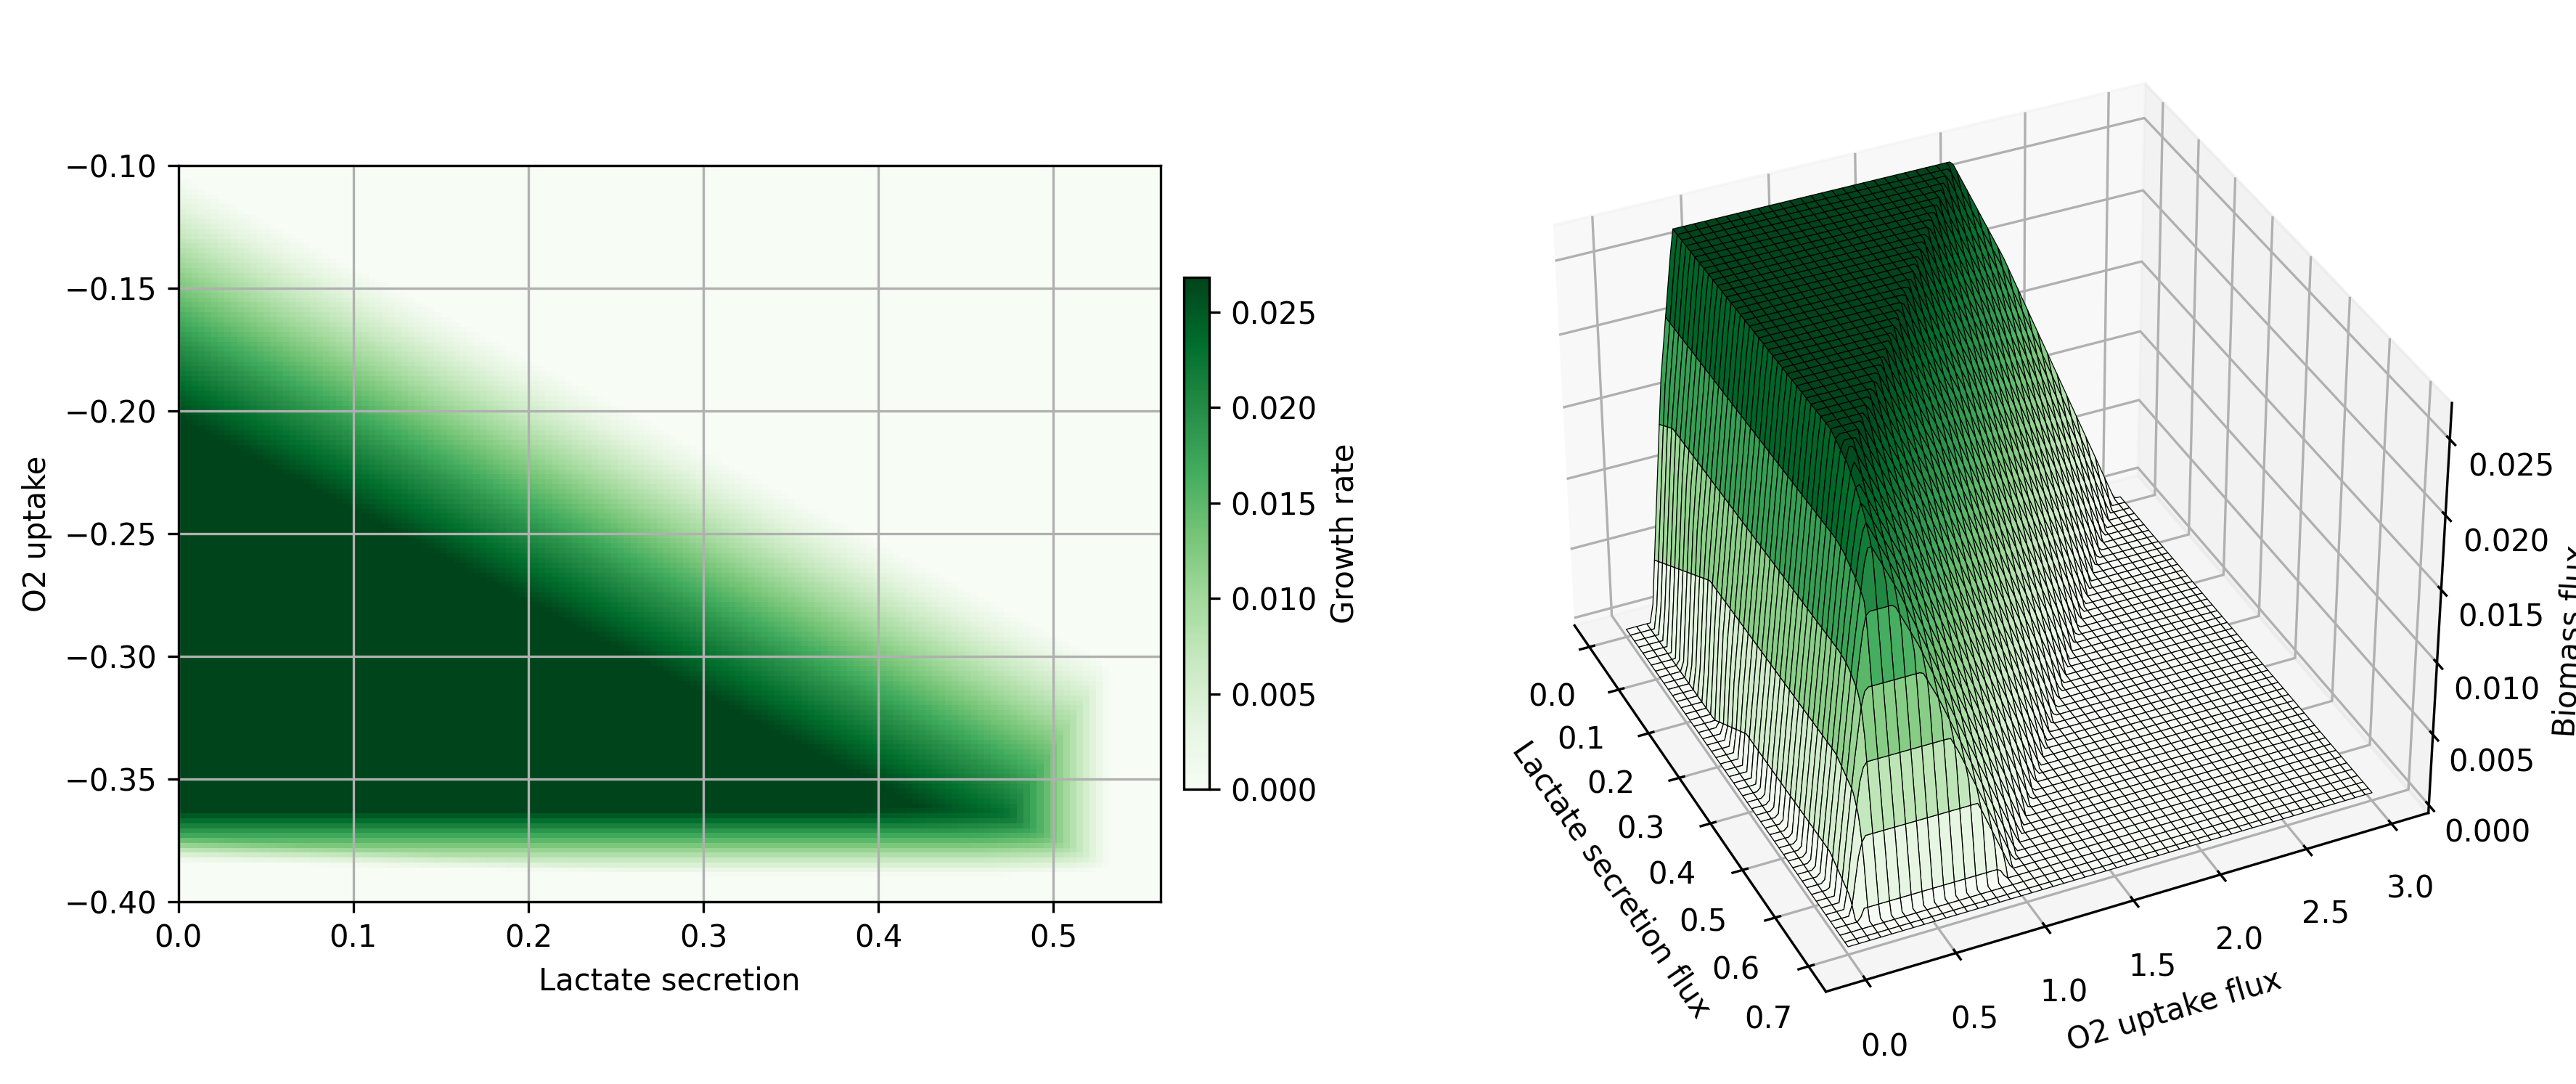

In [28]:
fig = plt.figure(figsize=(12,5), dpi=300)

show_phase_boundary = False

phase_boundary = np.logical_or(
    np.abs(rc_o2) > tol,
    np.abs(rc_lac) > tol
)

# ------------------
# Panel 1: Heatmap
# ------------------

ax1 = fig.add_subplot(1,2,1)

ax1.set_box_aspect(0.75)

print([lac_vals.min(), lac_vals.max(), o2_vals.min(), o2_vals.max()])

im = ax1.imshow(
    biomass,
    extent=[lac_vals.min(), lac_vals.max(), o2_vals.min(), o2_vals.max()],
    origin='lower',
    aspect='auto',
    cmap='Greens',
)

if show_phase_boundary:
    ax1.contour(
        LAC,
        O2,
        phase_boundary,
        levels=[0.5],
        colors='black',
        linewidths=1
    )

ax1.set_xlabel("Lactate secretion")
ax1.set_ylabel("O2 uptake")
ax1.grid()

# Colorbar only for heatmap
cbar = fig.colorbar(im, ax=ax1, shrink=0.5, pad=0.02)
cbar.set_label("Growth rate")


# ------------------
# Panel 2: 3D surface
# ------------------

ax2 = fig.add_subplot(1,2,2, projection='3d')

surf = ax2.plot_surface(
    LAC,
    O2,
    biomass,
    cmap='Greens',
    linewidth=0.3, 
    edgecolors='k',
    antialiased=True
)

if show_phase_boundary:
    ax2.plot(
        LAC[phase_boundary],
        O2[phase_boundary],
        biomass[phase_boundary],
        'k.',
        markersize=1
    )

ax2.set_xlabel('Lactate secretion flux')
ax2.set_ylabel('O2 uptake flux')
ax2.set_zlabel('Biomass flux')

ax2.view_init(elev=35, azim=-25)

fig.tight_layout()
fig.show()
fig.savefig("/home/mponce/Desktop/PPP.png")

# Finding the appropiate Lac bound

In [68]:
lac_rxn = model.reactions.R_EX_lac_L_e
o2_rxn = model.reactions.R_EX_o2_e

n = 1000

o2_vals = np.linspace(-0.1, -0.09, n)
biomass_vals_nolac = np.zeros(n)
biomass_vals_lac = np.zeros(n)
biomass_vals_free = np.zeros(n)

oxygen_vals = np.zeros((n,3))
lac_vals = np.zeros((n,3))

lac_lb = 0.52

for i in range(n):

    o2 = o2_vals[i]
    o2_rxn.bounds = (o2, 0)

    lac_rxn.bounds = (0.0, 0.0)
    sol = model.optimize()
    if sol.status == "optimal":
        biomass_vals_nolac[i] = sol.fluxes["R_biomass_reaction"]
        oxygen_vals[i,0] = sol.fluxes["R_EX_o2_e"]
        lac_vals[i,0] = sol.fluxes["R_EX_lac_L_e"]

    lac_rxn.bounds = (lac_lb, 0.7)
    sol = model.optimize()
    if sol.status == "optimal":
        biomass_vals_lac[i] = sol.fluxes["R_biomass_reaction"]
        oxygen_vals[i,1] = sol.fluxes["R_EX_o2_e"]
        lac_vals[i,1] = sol.fluxes["R_EX_lac_L_e"]
    else:
        biomass_vals_lac[i] = np.nan

    lac_rxn.bounds = (0.0, 0.7)
    sol = model.optimize()
    if sol.status == "optimal":
        biomass_vals_free[i] = sol.fluxes["R_biomass_reaction"]
        oxygen_vals[i,2] = sol.fluxes["R_EX_o2_e"]
        lac_vals[i,2] = sol.fluxes["R_EX_lac_L_e"]


/home/mponce/projects/devel/PhysiCelldFBA/venv/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Text(0, 0.5, 'Acetate uptake')

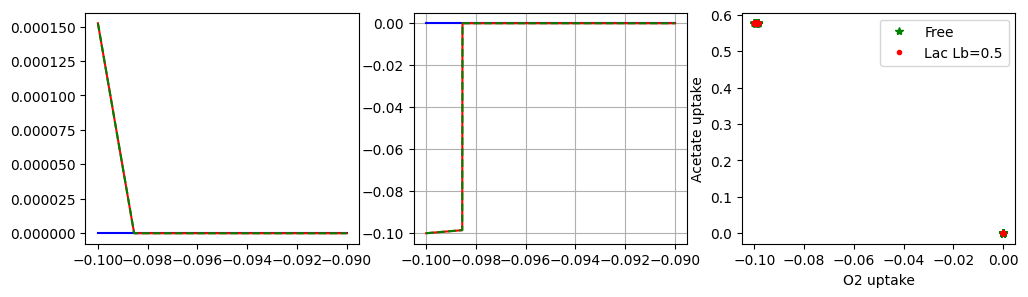

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

ax = axes[0]
ax.plot(o2_vals, biomass_vals_nolac, 'b', )
ax.plot(o2_vals, biomass_vals_lac, 'r')
ax.plot(o2_vals, biomass_vals_free, 'g--')

ax = axes[1]
ax.plot(o2_vals, oxygen_vals[:, 0], 'b', )
ax.plot(o2_vals, oxygen_vals[:, 1], 'r')
ax.plot(o2_vals, oxygen_vals[:, 2], 'g--')
ax.grid()

ax = axes[2]
ax.plot(oxygen_vals[:, 2], lac_vals[:, 2], 'g*', label="Free")
ax.plot(oxygen_vals[:, 1], lac_vals[:, 1], 'r.', label="Lac Lb=0.5")
ax.legend()


ax.set_xlabel("O2 uptake")
ax.set_ylabel("Acetate uptake")

In [79]:
df = pd.DataFrame({"biomass":biomass_vals_lac, "O2":o2_vals})
df.head(150).tail(30)

model.reactions.R_EX_o2_e.lower_bound = -0.098539
s = model.optimize()
print(s.objective_value)
print("hola")
# model.summary(s)
s

None
hola


/home/mponce/projects/devel/PhysiCelldFBA/venv/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


<Solution infeasible at 0x718482e036a0>

In [ ]:




reactions =  exchanges + ["R_biomass_reaction"]
n = 1000
m = len(reactions)

bounds = np.linspace(-1, 0.0, n)

fig, ax = plt.subplots(1,1, figsize=(12,4), sharex=True, sharey=True)


ax.plot(df1['R_biomass_reaction'], c='b', label='biomass')
ax.plot(df2['R_biomass_reaction'], c='r', label='biomass')
res1 = np.zeros((n,m))
for i,lb in enumerate(bounds):
    model.reactions.R_EX_o2_e.lower_bound = lb
    s = model.optimize()
    if s.status == 'optimal':
        lac = s.fluxes['R_EX_lac_L_e']
        print(f"Setting O2 lb {lb:.4f}. Status {s.status}. Lac ex: {lac:.4f} fopt: {s.objective_value:.4f}")
        res1[i,:] = s.fluxes[reactions].values
    else:
        break
df1 = pd.DataFrame(data=res1, index=bounds, columns=reactions)
print()

model.reactions.R_EX_lac_L_e.lower_bound = 0.0
model.reactions.R_EX_lac_L_e.upper_bound = 0.0
res2 = np.zeros((n,m))
for i,lb in enumerate(bounds):
    model.reactions.R_EX_o2_e.lower_bound = lb
    s = model.optimize()
    res2[i,0] = lb
    if s.status == 'optimal':
        lac = s.fluxes['R_EX_lac_L_e']
        print(f"Setting O2 lb {lb:.4f}. Status {s.status}. Lac ex: {lac:.4f} fopt: {s.objective_value:.4f}")
        res2[i,:] = s.fluxes[reactions].values
    else:
        break

df2 = pd.DataFrame(data=res2, index=bounds, columns=reactions)

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,4), sharex=True)

ax = axes[0]
#ax.set_ylim((-1.5, 5))
for i in reactions[:-1]:
    if df1[i].abs().max() < 0.05:
        continue
    if df1[i].abs().max() > 4:
        continue
    ax.plot(df1[i], label=i[5:-2])
    
ax.legend(loc=0)

ax = axes[1]
#ax.set_ylim((-1.5, 5))
for i in reactions[:-1]:
    if df2[i].abs().max() < 0.05:
        continue
    if df2[i].abs().max() > 4:
        continue
    ax.plot(df2[i], label=i[5:-2])
ax.legend(loc=0)

fig, ax = plt.subplots(1,1, figsize=(12,4), sharex=True, sharey=True)


ax.plot(df1['R_biomass_reaction'], c='b', label='biomass')
ax.plot(df2['R_biomass_reaction'], c='r', label='biomass')


fig, ax = plt.subplots(1,1, figsize=(12,4), sharex=True, sharey=True)


ax.plot(df1['R_EX_lac_L_e'], c='b', label='lactate')
